In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Resizing , Rescaling , InputLayer , Conv2D , BatchNormalization , MaxPool2D , Flatten , Dropout , Dense , GlobalAveragePooling2D , Input
from tensorflow.keras.regularizers import L2
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy , F1Score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix , roc_curve
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle
import cv2

In [5]:
!unzip "/content/drive/MyDrive/deep fake detection/Data.zip" -d "/content/data"

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/Data/test/AI/4663.jpg  
  inflating: /content/data/Data/test/AI/4678.jpg  
  inflating: /content/data/Data/test/AI/4685.jpg  
  inflating: /content/data/Data/test/AI/4691.jpg  
  inflating: /content/data/Data/test/AI/4692.jpg  
  inflating: /content/data/Data/test/AI/4694.jpg  
  inflating: /content/data/Data/test/AI/4695.jpg  
  inflating: /content/data/Data/test/AI/4699.jpg  
  inflating: /content/data/Data/test/AI/4702.jpg  
  inflating: /content/data/Data/test/AI/4705.jpg  
  inflating: /content/data/Data/test/AI/4714.jpg  
  inflating: /content/data/Data/test/AI/4717.jpg  
  inflating: /content/data/Data/test/AI/4724.jpg  
  inflating: /content/data/Data/test/AI/4728.jpg  
  inflating: /content/data/Data/test/AI/4736.jpg  
  inflating: /content/data/Data/test/AI/4742.jpg  
  inflating: /content/data/Data/test/AI/4744.jpg  
  inflating: /content/data/Data/test/AI/4752.jpg  
  inflating: /content/data/Data

In [4]:
train_directory = "/content/data/Data/train"
test_directory = "/content/data/Data/test"
val_directory = "/content/data/Data/val"
CONFIGURATION = {
    'BATCH_SIZE' : 32 ,
    'IM_SIZE' : 256 ,
    'LEARNING_RATE' : 0.0001,
    'REGULARIZATION_RATE' : 0.001 ,
    'DROPOUT_RATE' : 0.3 ,
    'KERNEL_SIZE' : 3 ,
    'N_FILTERS' : 6 ,
    'N_EPOCHS' : 25 ,
    'POOL_SIZE' : 2 ,
    'N_STRIDES' : 1 ,
    'DENSE1' : 128 ,
    'DENSE2' : 64 ,
    'DENSE3' : 32 ,
    'NUM_CLASSES' : 2

}
class_names = ['AI' , 'REAL']  # real - 1 , ai - 0

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_directory,
    labels='inferred',
    label_mode='binary',
    class_names=class_names,
    color_mode='rgb',
    batch_size=CONFIGURATION['BATCH_SIZE'],
    image_size=(CONFIGURATION['IM_SIZE'] , CONFIGURATION['IM_SIZE']),
    shuffle=True,
    seed=43,
)

Found 3743 files belonging to 2 classes.


In [7]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_directory,
    labels='inferred',
    label_mode='binary',
    class_names=class_names,
    color_mode='rgb',
    batch_size=CONFIGURATION['BATCH_SIZE'],
    image_size=(CONFIGURATION['IM_SIZE'] , CONFIGURATION['IM_SIZE']),
    shuffle=False,
    seed=43,
)

Found 527 files belonging to 2 classes.


In [8]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_directory,
    labels='inferred',
    label_mode='binary',
    class_names=class_names,
    color_mode='rgb',
    batch_size=CONFIGURATION['BATCH_SIZE'],
    image_size=(CONFIGURATION['IM_SIZE'] , CONFIGURATION['IM_SIZE']),
    shuffle=False,
    seed=43,
)

Found 1086 files belonging to 2 classes.


In [9]:
for image , label in train_ds.unbatch().take(1):
  print(label)

tf.Tensor([0.], shape=(1,), dtype=float32)


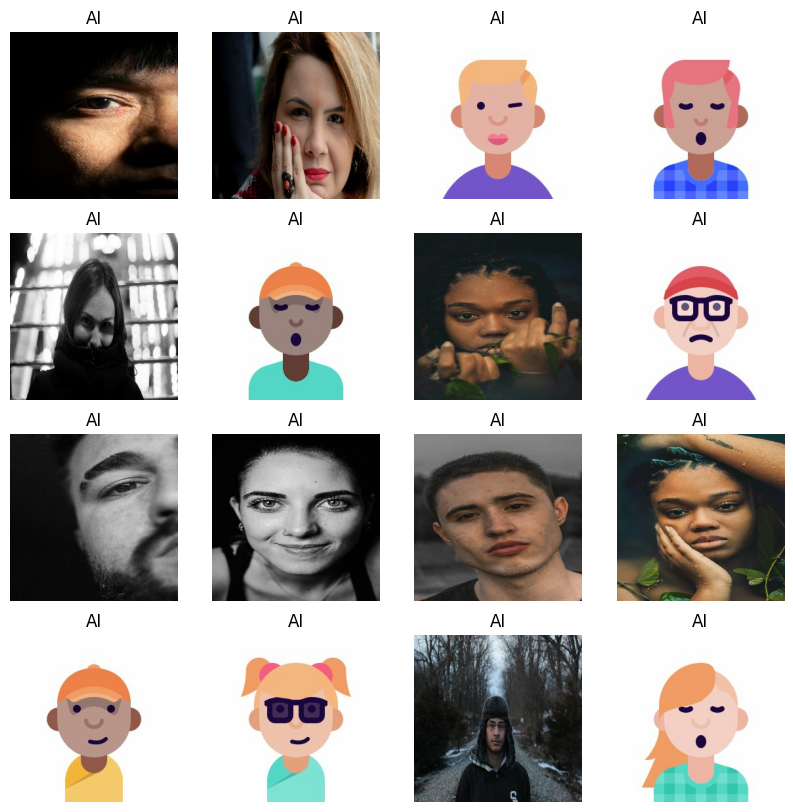

In [10]:
plt.figure(figsize = (10 , 10 ))
for i in range(16):
  for image , label in train_ds.unbatch().take(1):
    plt.subplot(4 , 4  , i+1)
    plt.imshow(image / 255.)
    plt.title(class_names[tf.argmax(label , axis = 0).numpy()])
    plt.axis('off')

In [11]:
resize_rescale_layer = Sequential([
    Resizing(CONFIGURATION['IM_SIZE'] , CONFIGURATION['IM_SIZE']),
    Rescaling(1./255.)
])

In [14]:
training_dataset = (
    train_ds
    .prefetch(tf.data.AUTOTUNE)
)
validation_dataset =(
    val_ds
    .prefetch(tf.data.AUTOTUNE)
)
test_dataset =(
    test_ds
    .prefetch(tf.data.AUTOTUNE)
)

In [15]:
lenet_model = tf.keras.Sequential([
    InputLayer(input_shape = (None , None, 3)),
    resize_rescale_layer,

    Conv2D(filters = CONFIGURATION['N_FILTERS'] , kernel_size = CONFIGURATION['KERNEL_SIZE'] , strides = CONFIGURATION['N_STRIDES'] , activation = 'relu' , kernel_regularizer = L2(CONFIGURATION['REGULARIZATION_RATE'])),
    BatchNormalization(),
    MaxPool2D(pool_size = CONFIGURATION['POOL_SIZE'] , strides = CONFIGURATION['N_STRIDES']*2),
    Dropout(rate = CONFIGURATION['DROPOUT_RATE']),

    Conv2D(filters = CONFIGURATION['N_FILTERS']*2 + 4, kernel_size = CONFIGURATION['KERNEL_SIZE'] , strides = CONFIGURATION['N_STRIDES'] , activation = 'relu' , kernel_regularizer = L2(CONFIGURATION['REGULARIZATION_RATE'])),
    BatchNormalization(),
    MaxPool2D(pool_size = CONFIGURATION['POOL_SIZE'] , strides = CONFIGURATION['N_STRIDES']*2),
    Dropout(rate = CONFIGURATION['DROPOUT_RATE']),

    Flatten(),

    Dense(CONFIGURATION['DENSE1'] , activation = 'relu' , kernel_regularizer=L2(CONFIGURATION['REGULARIZATION_RATE'])),
    BatchNormalization(),
    Dropout(rate = CONFIGURATION['DROPOUT_RATE']),

    Dense(CONFIGURATION['DENSE2'] , activation = 'relu' , kernel_regularizer=L2(CONFIGURATION['REGULARIZATION_RATE'])),
    BatchNormalization(),

    Dense(CONFIGURATION['DENSE2'] , activation = 'relu' , kernel_regularizer=L2(CONFIGURATION['REGULARIZATION_RATE'])),
    BatchNormalization(),


    Dense(2 , activation = "sigmoid")
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [16]:
lenet_model.compile(loss = BinaryCrossentropy() , optimizer = Adam(learning_rate = CONFIGURATION['LEARNING_RATE'] ), metrics = [BinaryAccuracy() , F1Score()])

In [17]:
# history_lenet = lenet_model.fit(training_dataset , validation_data = validation_dataset , epochs = CONFIGURATION['N_EPOCHS'] , verbose = 1)

In [18]:
# plt.plot(history_lenet.history['loss'])
# plt.plot(history_lenet.history['val_loss'])
# plt.title('model loss')
# plt.ylabel('loss')
# plt.xlabel('epoch')

In [19]:
# print(history_lenet.history.keys())

In [20]:
# plt.plot(history_lenet.history['binary_accuracy'])
# plt.plot(history_lenet.history['val_binary_accuracy'])
# plt.title('model accuracy')
# plt.ylabel('loss')
# plt.xlabel('epoch')

In [21]:
backbone = ResNet50 (
    include_top = False ,
    weights = 'imagenet' ,
    input_shape = (CONFIGURATION['IM_SIZE'] , CONFIGURATION['IM_SIZE'] , 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [22]:
backbone.trainable = False # freeze the model

In [23]:
modelcheckpointcallback = ModelCheckpoint(
    filepath = "resnet_model.keras",
    monitor = "val_loss",
    save_best_only = True,
    mode = 'min',
    verbose = 1
)

In [24]:
# resnet_model = Sequential([
#     resize_rescale_layer ,
#     backbone ,
#     GlobalAveragePooling2D() ,
#     Dense(CONFIGURATION['DENSE1'] , activation = 'relu'),
#     BatchNormalization() ,
#     Dense(CONFIGURATION['DENSE2'] , activation = 'relu'),
#     BatchNormalization() ,
#     Dense(CONFIGURATION['DENSE1'] , activation = 'relu'),
#     BatchNormalization() ,
#     Dense( 2 , activation = 'sigmoid')
# ])

In [25]:
# resnet_model.compile(loss = BinaryCrossentropy() , optimizer = Adam(learning_rate = CONFIGURATION['LEARNING_RATE']) , metrics = [BinaryAccuracy() , F1Score()])

In [26]:
# history_resnet = resnet_model.fit(training_dataset , validation_data = validation_dataset , epochs = CONFIGURATION['N_EPOCHS'] + 15 , verbose = 1 , callbacks=[modelcheckpointcallback])

In [27]:
# plt.plot(history_resnet.history['loss'])
# plt.plot(history_resnet.history['val_loss'])
# plt.title('model loss')
# plt.ylabel('loss')
# # plt.xlabel('epoch')

In [28]:
# plt.plot(history_resnet.history['binary_accuracy'])
# plt.plot(history_resnet.history['val_binary_accuracy'])
# plt.title('model accuracy')
# plt.ylabel('loss')
# plt.xlabel('epoch')

In [29]:
# resnet_model.save("resnet_model.keras")
# with open("history_resnet.pkl" , 'wb') as file:
#   pickle.dump(history_resnet.history ,  file)

In [30]:
# from google.colab import files
# files.download("resnet_model.keras")
# files.download("history_resnet.pkl")

In [31]:
input_tensor = Input(shape = (CONFIGURATION['IM_SIZE'] , CONFIGURATION['IM_SIZE'] , 3))


x = backbone(input_tensor , training = False)  # here trainable false keeps batchnorm inference
x = GlobalAveragePooling2D()(x)
x = Dense(CONFIGURATION['DENSE1'] , activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dense(CONFIGURATION['DENSE2'] , activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dense(CONFIGURATION['DENSE3'] , activation = 'relu')(x)
x = BatchNormalization()(x)
final_output_tensor = Dense(1 , activation = 'sigmoid')(x)

fine_tuned = tf.keras.Model(inputs=input_tensor, outputs=final_output_tensor)

In [32]:
fine_tuned.compile(loss = BinaryCrossentropy() , optimizer = Adam(0.00001) , metrics = [BinaryAccuracy()])

In [33]:
fine_tuned.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,861,249 (91.02 MB)

 Trainable params: 273,089 (1.04 MB)

 Non-trainable params: 23,588,160 (89.98 MB)

In [ ]:
history_fine_tuned = fine_tuned.fit(training_dataset , validation_data = validation_dataset , epochs = 15)

In [ ]:
 ## now let us do fine tuning

fine_tuned.trainable = True

In [ ]:
fine_tuned.summary()

In [ ]:
for layer in backbone.layers[:-20]:
    layer.trainable = False

In [ ]:
fine_tuned.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_fine_tuned = fine_tuned.fit(training_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks = [modelcheckpointcallback]
)

In [ ]:
fine_tuned.save("fine_tuned_model.keras")
with open("history_fine_tuned.pkl" , 'wb') as file:
  pickle.dump(history_fine_tuned.history ,  file)

In [ ]:
from google.colab import files
files.download('fine_tuned_model.keras')
# files.download('history_fine_tuned.pkl')

In [9]:
fine_tuned_model = tf.keras.models.load_model("/content/drive/MyDrive/deep fake detection/fine_tuned_model.keras")
with open("/content/drive/MyDrive/deep fake detection/history_fine_tuned.pkl" , "rb") as file:
  history_fine_tuned = pickle.load(file)

Text(0.5, 0, 'epoch')

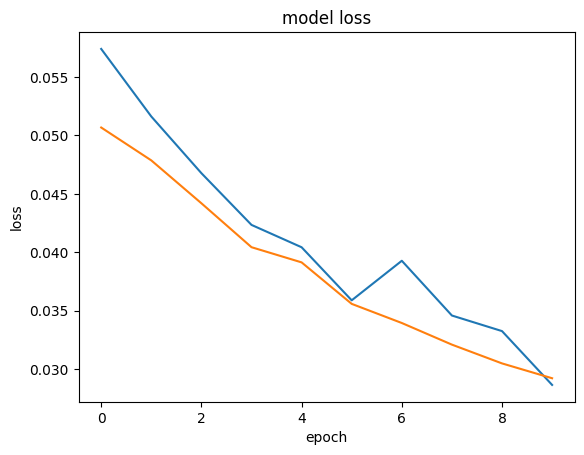

In [10]:
plt.plot(history_fine_tuned['loss'])
plt.plot(history_fine_tuned['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

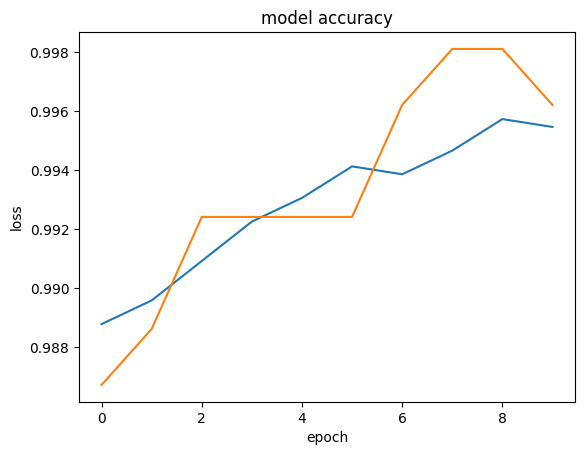

In [11]:
plt.plot(history_fine_tuned['accuracy'])
plt.plot(history_fine_tuned['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('loss')
plt.xlabel('epoch')

In [ ]:
def process_image(path):
  image = cv2.imread(path)
  image = cv2.resize(image , (256 , 256))
  image = tf.constant(image , dtype=tf.float32)
  image = tf.expand_dims(image , axis = 0)
prediction = fine_tuned_model.predict(image)
if prediction[0][0] > 0.69:
  print("REAL")
else:
  print("AI")
print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
REAL
[[0.70220053]]


In [13]:
y_true = []
y_pred = []

for image , label in test_ds:
  preds = fine_tuned_model.predict(image)

  y_true.extend(label.numpy())
  y_pred.extend(preds.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [44]:
threshold = 0.7
cm = confusion_matrix(y_true , np.array(y_pred) > threshold)
print(cm)
# 99.45% accuracy

[[541   3]
 [  3 539]]


<Axes: >

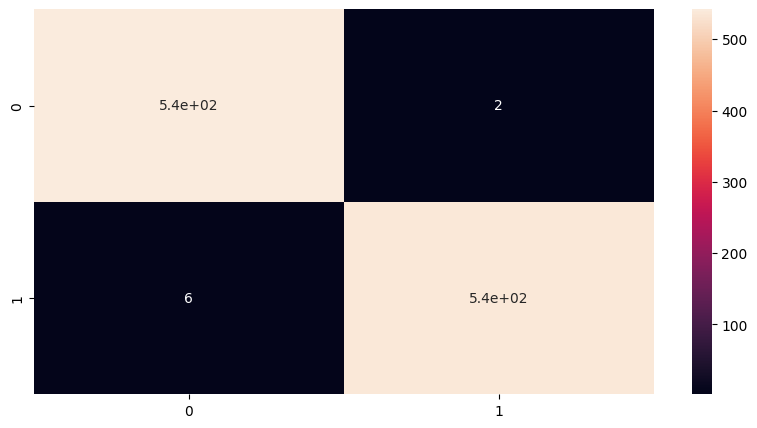

In [36]:
plt.figure(figsize = (10 , 5))
sns.heatmap(cm , annot = True)

In [15]:
fpr , tpr , thresholds = roc_curve(y_true , y_pred)
print(len(fpr) , len(tpr) , len(thresholds))

38 38 38


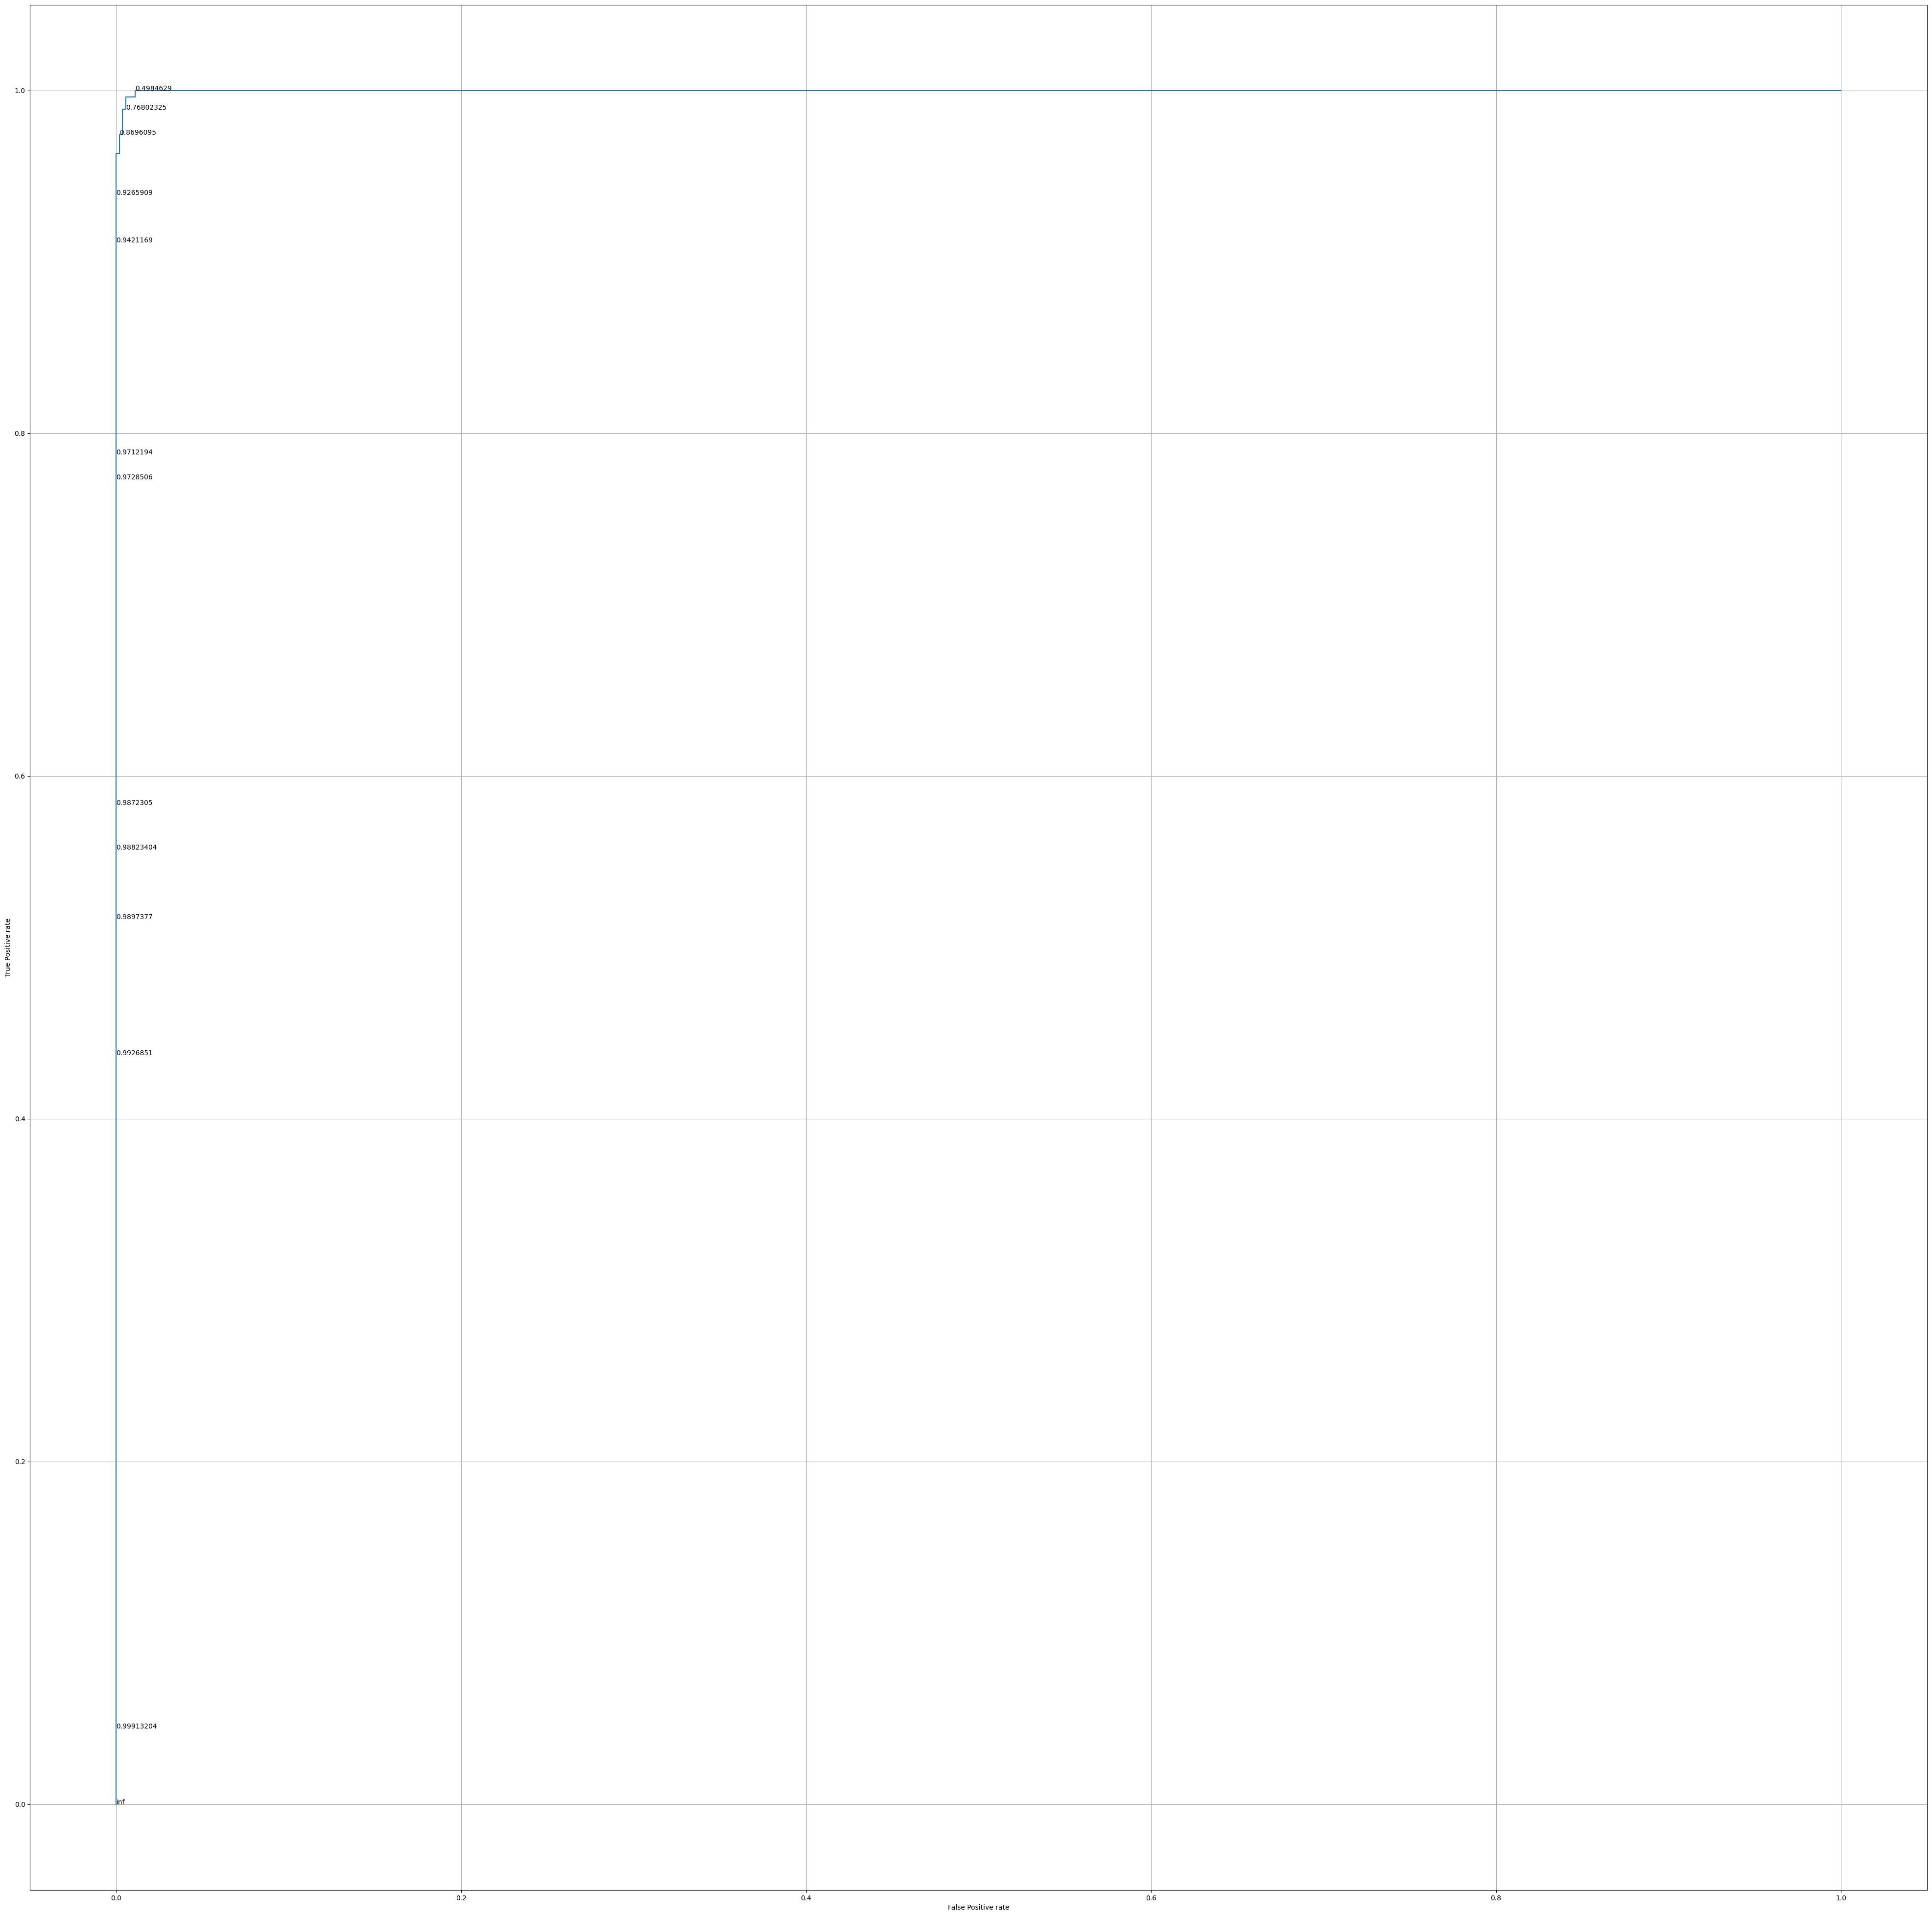

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(50,50))
plt.plot(fpr , tpr )
plt.xlabel('False Positive rate')
plt.ylabel('True Positive rate')
skip  = 3
for i in range(0 , len(thresholds) , skip):
    plt.text(fpr[i] , tpr[i] , thresholds[i])
plt.grid(True)
plt.show()